In [3]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 

In [ ]:
# y = 2x1 + 3x2 - x3 + 4.5 x4 + 2
# w1 = 2, w2 = 3 , w3 = -1 , w4 = 4.5 , b = 2

# xtest = [[1,2,3,4],[2,4,6,8]]  -> each list is a sample of data (row)  
# xtest is a list of list -> small list is a sample of data (row) -> big list is the all rows 
# ytest [[2+6-3+18+2],[4+12-6+36+2]] =[[25],[48]]  -> for each small list there is a value as result from equation  

In [4]:
w = np.array([2,3,-1,4.5])
b = 2
xtest = np.array([[1,2,3,4],[2,4,6,8]])
ytest = w*xtest 
ytest = np.sum(ytest,axis=1) + b
ytest

array([25., 48.])

In [18]:
def gradient_descent_multipleFeatures(xtest,ytest):
    n = len(xtest) # number of samples (rows)
    n_features = len(xtest[0]) # no. of features for each sample 
    w = np.array([0]*n_features)   # weight for each feature initialize to zero 
    b = 0     # intercept 
    lr = 0.01   # learning rate

    for i in range(10000):
        yhat = w*xtest
        yhat = np.sum(yhat,axis=1) + b

        error = yhat - ytest
        dedw = np.array([0]*n_features)
        for j in range (n_features):
            dedw[j] = (2/n) * sum(error * xtest[:, j])
        dedb = (2/n)* sum(error)

        w = w - lr * dedw
        b = b - lr * dedb

    mse = sum((yhat-ytest)**2) / n
    mae = sum(abs(yhat-ytest)) / n   
        
    return{
        "w":w,
        "b":b,
        "MSE":mse,
        "MAE":mae
    }
    

In [19]:
res = gradient_descent_multipleFeatures(xtest=xtest,ytest=ytest)
res

{'w': array([0.8 , 1.59, 2.38, 3.09]),
 'b': np.float64(1.2799999999999836),
 'MSE': np.float64(0.05760000000000266),
 'MAE': np.float64(0.24000000000000554)}

In [20]:
weights =  res["w"]
b = res["b"]

In [21]:
y_predicted = weights*xtest 
y_predicted = np.sum(y_predicted,axis =1) + b 
y_predicted 

array([24.76, 48.24])

### plot the y and yhat of each sample to see difference 

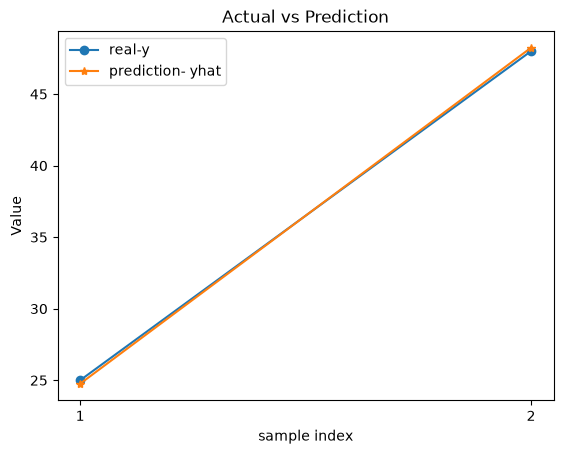

In [25]:
xplot = [1,2]  # for each sample 
plt.xlabel("sample index")
plt.ylabel("Value")
plt.title("Actual vs Prediction")
plt.plot(xplot,ytest,label ="real-y",marker="o")
plt.plot(xplot,y_predicted,label ="prediction- yhat",marker="*")
plt.legend(loc = 0)
plt.xticks(xplot)
plt.show()